In [10]:
# Install packages if needed
# install.packages("ggplot2")
# install.packages("ggridges")
# install.packages("tidyr")
# install.packages("ggrepel")
# install.packages("dplyr")

library(ggplot2)
library(ggridges)
library(tidyr)
library(ggrepel)
library(dplyr)

plot_gene_expression <- function(norm_expr_file, deg_file, dataset_name, save_folder) {
  # Read normalized expression data (wide format)
  norm_expr <- read.csv(norm_expr_file, header = TRUE, check.names = FALSE)
  
  # Convert to long/tidy format
  norm_expr_long <- pivot_longer(
    norm_expr,
    cols = -GENE_ID,
    names_to = "Sample",
    values_to = "Expression"
  )
  
  # Read DEG results
  deg <- read.csv(deg_file, header = TRUE)
  
  # Create output folder if needed
  if (!dir.exists(save_folder)) {
    dir.create(save_folder, recursive = TRUE)
  }

  norm_expr_long$LogExpression <- log1p(norm_expr_long$Expression)

  # --- Boxplot (styled like your reference image) ---
  p1 <- ggplot(norm_expr_long, aes(x = Sample, y = LogExpression)) +
    geom_boxplot(
      fill = "skyblue", color = "black",
      outlier.shape = 8, outlier.size = 3
    ) +
    theme_bw() +
    labs(
      title = paste0(dataset_name, " Boxplot"),
      x = "Sample", y = "Log Normalized Expression"
    ) +
    coord_cartesian(ylim = c(-1, 1))

  ggsave(filename = file.path(save_folder, paste0(dataset_name, "_boxplot.png")),
         plot = p1, width = 7, height = 7)
  
  # --- Ridge plot (adjusted bandwidth to avoid emptiness) ---
  p2 <- ggplot(norm_expr_long, aes(x = LogExpression, y = Sample, fill = Sample)) +
    geom_density_ridges(alpha = 0.7, bandwidth = 0.2) +
    labs(
      title = paste0(dataset_name, " Ridge Plot"),
      x = "Log Normalized Expression", y = "Sample"
    )
  ggsave(filename = file.path(save_folder, paste0(dataset_name, "_ridgeplot.png")),
         plot = p2, width = 7, height = 7)
  
  # --- MA plot (labels top significant genes) ---
  # Select top 10 DEGs with significant padj
  top_genes <- deg %>% filter(padj < 0.05) %>%
    arrange(-abs(log2FoldChange)) %>% slice(1:10)
  
  p3 <- ggplot(deg, aes(x = log10(baseMean), y = log2FoldChange)) +
    geom_point(aes(color = padj < 0.05), alpha = 0.4) +
    scale_color_manual(values = c("grey", "red")) +
    theme_bw() +
    geom_hline(yintercept = 0, linetype = "dashed") +
    geom_text_repel(
      data = top_genes,
      aes(label = gene),
      size = 3, box.padding = 0.5, max.overlaps = 10
    ) +
    labs(
      title = paste0(dataset_name, " MA Plot"),
      x = "Mean of Normalized Counts (log10)",
      y = "Log2 Fold Change",
      color = "Significant"
    )
  ggsave(filename = file.path(save_folder, paste0(dataset_name, "_maplot.png")),
         plot = p3, width = 7, height = 7)
}

# Example usage for three datasets
plot_gene_expression("Normalized/GSE38265.csv", "ORA/GSE38265/DEGresults_HUES9_vs_iPSC.csv", "GSE38265", "Plots")
plot_gene_expression("Normalized/GSE239446_genenames.csv", "ORA/GSE239446/GSE239446_logfc1_new_DEG_iPSC_vs_NSC.csv", "GSE239446", "Plots")
plot_gene_expression("Normalized/GSE69626_genenames.csv", "ORA/GSE69626/DEG_OSKM_vs_ESC.csv", "GSE69626", "Plots")


Warning message:
"ggrepel: 6 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"Removed 28592 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


# HeatMap

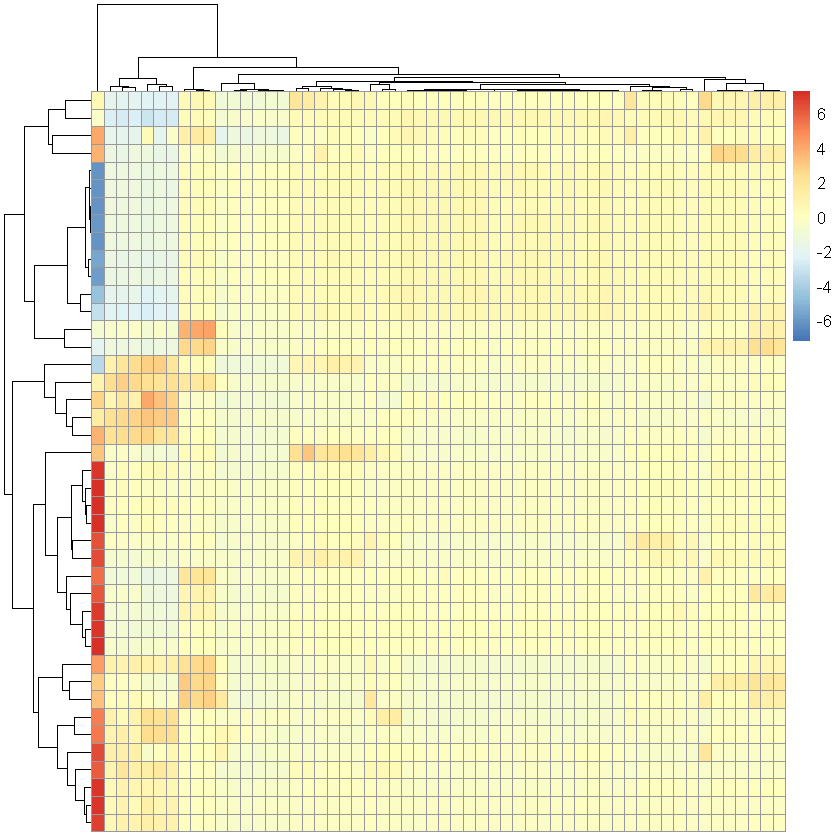

In [10]:
genes_of_interest <- c("GAB1", "SMAD2", "CCND2", "PPP1R12B", "KCNJ13", "PIK3CA", "PIK3R1", "AKT", "PTEN",
                      "mTOR", "VEGF", "EGFR", "MYC", "KIT", "ERBB2", "MET", "FGFR2", "FGFR3", "PDGFRA",
                      "ITGA1", "ITGA2", "ITGA3", "ITGA4", "ITGA5", "ITGA6", "ITGA7", "ITGA8", "ITGA9",
                      "ITGA10", "ITGA11", "ITGAD", "ITGAE", "ITGAL", "ITGAM", "ITGAV", "ITGA2B", "ITGB1",
                      "ITGB2", "ITGB3", "ITGB4", "ITGB5", "ITGB6", "ITGB7", "ITGB8")

create_combined_heatmap <- function(csv_files, genes_of_interest) {
  library(pheatmap)
  
  combined_data <- NULL
  for (file in csv_files) {
    data <- read.csv(file, stringsAsFactors = FALSE, check.names = FALSE)
    colnames(data)[1] <- "Gene"
    if (is.null(combined_data)) {
      combined_data <- data
    } else {
      combined_data <- merge(combined_data, data, by = "Gene", all = TRUE)
    }
  }
  
  combined_data_agg <- aggregate(. ~ Gene, combined_data, function(x) mean(as.numeric(x), na.rm=TRUE))
  
  rownames(combined_data_agg) <- toupper(combined_data_agg$Gene)
  combined_data_agg$Gene <- NULL
  
  genes_of_interest_upper <- toupper(genes_of_interest)
  
  filtered_data <- combined_data_agg[rownames(combined_data_agg) %in% genes_of_interest_upper, , drop=FALSE]
  
  expr_matrix <- as.matrix(sapply(filtered_data, function(x) as.numeric(as.character(x))))
  rownames(expr_matrix) <- rownames(filtered_data)
  
  expr_matrix[is.na(expr_matrix)] <- 0
  
  pheatmap(expr_matrix,
           scale = "row",
           clustering_distance_rows = "euclidean",
           clustering_method = "complete",
           show_rownames = FALSE,
           show_colnames = FALSE,
           )
}

# Example usage:
create_combined_heatmap(
  c("Normalized/GSE38265.csv", "Normalized/GSE69626_genenames.csv", "Normalized/GSE239446_genenames.csv"),
  genes_of_interest
)
